# Moon Classification with N01
In this example, we will build a multi-input, single-output neural network model to classify toy samples into two categories.



## 1. Load Raw Data
[scikit-learn](https://scikit-learn.org/stable/index.html) is a handy machine learning library for Python. 
It provides a handful of artificial and real [datasets](https://scikit-learn.org/stable/api/sklearn.datasets.html) for people practicing ML algorithms.

Among the modules and methods in `sklearn.datasets`, [make_moons](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html#sklearn.datasets.make_moons) creates two interleaving half circles on the 2-D plane.
 

First 10 samples of the raw features: 
[[-0.86691851 -0.32027284]
 [ 1.70922817 -0.66094909]
 [ 0.95477398  0.28453102]
 [ 0.14465106  0.33336045]
 [ 0.58070122  0.65058253]
 [ 1.33531488 -0.2647643 ]
 [ 1.46344736 -0.55310411]
 [-1.20787839  0.52778545]
 [ 0.47737585 -0.2020379 ]
 [ 1.45674566 -0.27188258]]
Shape of the raw features: (1024, 2)

First 10 samples of the raw labels: [0 1 0 1 0 1 1 0 1 1]
Shape of the raw labels: (1024,)


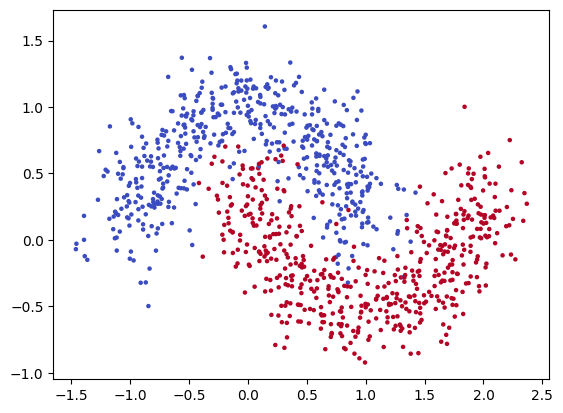

In [2]:
from sklearn.datasets import make_moons
import numpy as np
import matplotlib.pyplot as plt

# Create dataset
features_raw, labels_raw = make_moons(n_samples=1024, noise=0.2, random_state=3321)

# First impressions
print(f"First 10 samples of the raw features: \n{features_raw[:10]}")  # (x, y) coordinates
print(f"Shape of the raw features: {features_raw.shape}")
print(f"\nFirst 10 samples of the raw labels: {labels_raw[:10]}")
print(f"Shape of the raw labels: {labels_raw.shape}")

# Visualize
plt.scatter(
    features_raw[:, 0], # feature 1 value, x coords
    features_raw[:, 1], # feature 2 value, y coords
    s=5*np.ones(labels_raw.size), # marker size all set to 1
    c=labels_raw, # colorized labels: 0:blue, 1:red
    cmap='coolwarm'  # color map
)


### 1.1 Pre-Process the Data
1. Rescale features in range of $[-1, 1]$ on both dimensions.
2. Reformat the raw labels array into a column vector.

First 10 samples of the rescaled features: 
[[-0.36607231 -0.19946448]
 [ 0.72175308 -0.41163612]
 [ 0.4031709   0.17720464]
 [ 0.06108158  0.20761539]
 [ 0.24521179  0.40517987]
 [ 0.56386131 -0.16489401]
 [ 0.61796761 -0.34447074]
 [-0.5100489   0.3287024 ]
 [ 0.20158075 -0.1258283 ]
 [ 0.61513769 -0.16932724]]
Shape of the rescaled features: (1024, 2)

First 10 samples of the reformatted labels: 
[[0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]]
Shape of the reformatted labels: (1024, 1)


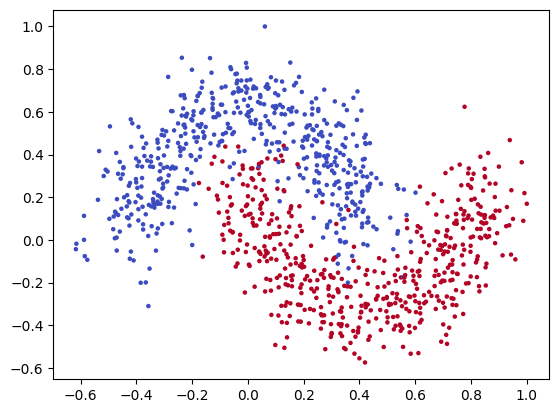

In [3]:
# Rescale by max
features_train = features_raw / features_raw.max(axis=0)

# Reshape labels
labels_train = labels_raw.reshape(-1, 1)

print(f"First 10 samples of the rescaled features: \n{features_train[:10]}")  # (x, y) coordinates
print(f"Shape of the rescaled features: {features_train.shape}")
print(f"\nFirst 10 samples of the reformatted labels: \n{labels_train[:10]}")
print(f"Shape of the reformatted labels: {labels_train.shape}")

# Visualize
plt.scatter(
    features_train[:, 0], 
    features_train[:, 1], 
    s=5*np.ones(labels_train.size), 
    c=labels_train, 
    cmap='coolwarm'
)


## 2. Sigmoid Activated Multi-Input, Single-Output Model
 
$$\hat{\mathbf{y}} = \sigma(\mathbf{z}) = \sigma(\mathbf{X} \cdot \mathbf{w}^T + \mathbf{b})$$

Where, $\mathbf{w}$ holds the weight parameters in a row vector with 2 elements.

$\mathbf{b}$ holds the bias parameter in a column vector with 1024 identical elements.

$\mathbf{X}$ contains features ($x$ and $y$ coordinates) in a matrix with 1024 rows and 2 columns.

$\hat{\mathbf{y}}$ is the model predictions in a column vector with 1024 elements.
 
$\sigma (\mathbf{z}) = 1 / (1 + e^{-\mathbf{z}})$ compress the output of the linear function $\mathbf{X} \cdot \mathbf{w}^T + \mathbf{b}$
within range: $[0, 1]$.


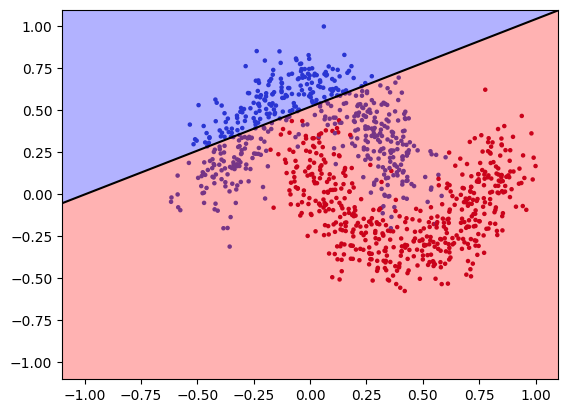

In [4]:
# Define Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Define model
def forward(in_features, weights, bias):
    z = np.dot(in_features, weights.T) + bias
    preds = sigmoid(z)
    return preds

# Sanity check
w_dummy = np.array([[1.2, -2.3]]) 
b_dummy = 1.2
preds_dummy = forward(features_train, w_dummy, b_dummy)

# Visualize decision boundary
# Scatter plot of the training data
plt.scatter(features_train[:, 0], features_train[:, 1], s=5*np.ones(labels_train.size), c=labels_train, cmap='coolwarm')
# Plot the decision boundary line
db_x = np.linspace(-1.1, 1.1, 1000)
db_y = (-b_dummy - w_dummy[0, 0] * db_x) / w_dummy[0, 1]
plt.plot(db_x, db_y, 'k')
# Create a meshgrid of points over the feature space
xx, yy = np.meshgrid(np.linspace(-1.1, 1.1, 200),
                     np.linspace(-1.1, 1.1, 200))
zz = sigmoid(w_dummy[0, 0] * xx + w_dummy[0, 1] * yy + b_dummy) - 0.5
plt.contourf(xx, yy, zz, levels=[-np.inf, 0, np.inf], colors=['blue', 'red'], alpha=0.3)


### Binary Cross-Entropy Loss
$\mathcal{L}(\hat{\mathbf{y}}, \mathbf{y}) = \frac{1}{M} \sum_{i=1}^{M} -{}^{(i)}y \ln {}^{(i)}\hat{y} - (1 - {}^{(i)}y) \ln (1 - {}^{(i)}\hat{y}) = \overline{-\mathbf{y} \ln \hat{\mathbf{y}} - (1 - \mathbf{y}) \ln (1 - \hat{\mathbf{y}})}$

#### Gradient computation



In [5]:
def bce_fn(preds, labels):
    loss = -labels * np.log(preds) - (1 - labels) * np.log(1 - preds)
    return np.mean(loss)

print(f"BCE loss of the dummy predictions: {bce_fn(preds=preds_dummy, labels=labels_train)}")

BCE loss of the dummy predictions: 0.5375827408033467


## 4. Gradient of BCE Loss

$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{1}{M} (\hat{\mathbf{y}} - \mathbf{y})^T \cdot \mathbf{X}$

$\frac{\partial \mathcal{L}}{\partial b} = \overline{(\hat{\mathbf{y}} - \mathbf{y})}$

In [6]:
def grad(in_features, preds, labels):
    # dw = 1 / labels.shape[0] * ((preds - labels).T @ in_features)  # dL/dw
    dw = 1 / labels.shape[0] * np.dot((preds - labels).T, in_features)  # dL/dw
    db = np.mean(preds - labels)  # dL/db 
    return dw, db

dw_dummy, db_dummy = grad(features_train, preds_dummy, labels_train)
print(f"Gradient of loss w.r.t. weights: {dw_dummy}")
print(f"Gradient of loss w.r.t. bias: {db_dummy}")

Gradient of loss w.r.t. weights: [[-0.01152135  0.09432015]]
Gradient of loss w.r.t. bias: 0.21087701625458344


## 5. Gradient Descent Model Parameter Optimization

Initial model parameters: w = [[6.04113912e-05 7.70937715e-05]], b = -2.5169506594721632e-05
loss @ 1 iteration: 0.6931498508682241
loss @ 2 iteration: 0.6710112378055199
loss @ 3 iteration: 0.6505539774557622
loss @ 4 iteration: 0.6316396199491454
loss @ 5 iteration: 0.6141398613190934
loss @ 6 iteration: 0.5979359998260215
loss @ 7 iteration: 0.5829185115437263
loss @ 8 iteration: 0.5689866451150005
loss @ 9 iteration: 0.5560479918362933
loss @ 10 iteration: 0.5440180197079426
loss @ 11 iteration: 0.5328195766984282
loss @ 12 iteration: 0.522382375348672
loss @ 13 iteration: 0.5126424722465803
loss @ 14 iteration: 0.5035417545639989
loss @ 15 iteration: 0.49502744339651994
loss @ 16 iteration: 0.4870516209787371
loss @ 17 iteration: 0.4795707864078697
loss @ 18 iteration: 0.47254544247735175
loss @ 19 iteration: 0.46593971463569517
loss @ 20 iteration: 0.45972100191089504
loss @ 21 iteration: 0.4538596588142509
loss @ 22 iteration: 0.4483287066907889
loss @ 23 iteration: 0.4431035726

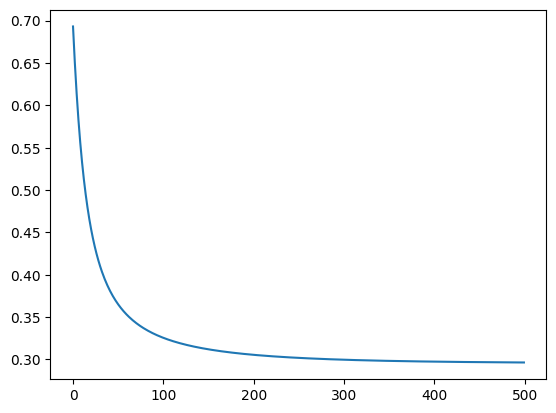

In [7]:
# Optimization iterations
w = np.random.normal(loc=0, scale=1e-4, size=(1, 2))  # loc: mean, scale: stddev, size: shape
b = np.random.normal(loc=0, scale=1e-4)
print(f"Initial model parameters: w = {w}, b = {b}")
num_iters = 500
learning_rate = 0.9
losses = []
for i in range(num_iters):
    preds_train = forward(features_train, w, b)
    dw, db = grad(features_train, preds_train, labels_train)
    loss = bce_fn(preds_train, labels_train)
    w = w - learning_rate * dw
    b = b - learning_rate * db
    print(f"loss @ {i+1} iteration: {loss}")
    # print(f"w = {w}, b = {b}")
    losses.append(loss)
print(f"final parameters: w = {w}, b = {b}")

# Observe loss values
plt.plot(losses)

## 5.1. Visualize Model Decision

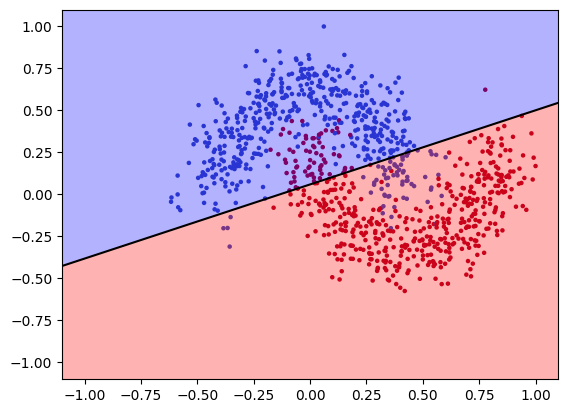

In [8]:
# Credit to ChatGPT
# Scatter plot of the training data
plt.scatter(features_train[:, 0], features_train[:, 1], s=5*np.ones(labels_train.size), c=labels_train, cmap='coolwarm')
# Plot the decision boundary line
db_x = np.linspace(-1.1, 1.1, 1000)
db_y = (-b - w[0, 0] * db_x) / w[0, 1]
plt.plot(db_x, db_y, 'k')
# Create a meshgrid of points over the feature space
xx, yy = np.meshgrid(np.linspace(-1.1, 1.1, 200),
                     np.linspace(-1.1, 1.1, 200))
zz = sigmoid(w[0, 0] * xx + w[0, 1] * yy + b) - 0.5
plt.contourf(xx, yy, zz, levels=[-np.inf, 0, np.inf], colors=['blue', 'red'], alpha=0.3)



## But, this model is not perfect due to its linearity. 

## 